# Preprocessing and data set creation

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style
from astropy.io import fits
import os
plt.style.use(astropy_mpl_style)
import transformations.transformations as _transformations
import torch
from torch.utils.data import Dataset, DataLoader
from random import shuffle

In [47]:
if not torch.cuda.is_available():
    raise Exception("Not enough GPU hardware devices available")

# Get the number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPU(s) available: {num_gpus}")

Number of GPU(s) available: 1


In [48]:
# scaling function
def ScaleImage(img, z = 0.1, experiment = 'HSC', new_size = 150):
    return _transformations.ScaleImage(img,experiment=experiment,new_size=new_size,z=z)

## Tracing function
set to 0 for no traces up to 4 for alot of traces

In [49]:
os.environ["DIFF_TRACE"]="0"

## Create dataset and load data

In [5]:
class TNGDataset(Dataset):
    def __init__(self, input_dir, band_filters, scaler_function=ScaleImage, split='train', train_percent=0.8, val_percent=0.1):
        self.band_filters = band_filters
        self.scaler_function = scaler_function
        self.data = []

        # Populate list of FITS files
        for root, dirs, files in os.walk(input_dir, topdown=False):
            for name in files:
                if name.endswith(".fits"):
                    self.data.append(os.path.join(root, name))

        # Shuffle the data to ensure random distribution
        shuffle(self.data)

        # Split data into training, validation, and test sets
        num_samples = len(self.data)
        train_end = int(train_percent * num_samples)
        val_end = train_end + int(val_percent * num_samples)

        if split == 'train':
            self.data = self.data[:train_end]
        elif split == 'validation':
            self.data = self.data[train_end:val_end]
        elif split == 'test':
            self.data = self.data[val_end:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_path = self.data[idx]
        with fits.open(file_path) as fitm:
            for fit_elem in fitm:
                if fit_elem.header["EXTNAME"] in self.band_filters:
                    img = self.scaler_function(fit_elem.data)
                    img_tensor = torch.tensor(img, dtype=torch.float32)  # Convert to tensor

                    metadata = {
                        "ORIGIN": fit_elem.header["ORIGIN"],
                        "SIMTAG": fit_elem.header["SIMTAG"],
                        "SNAPNUM": fit_elem.header["SNAPNUM"],
                        "SUBHALO": fit_elem.header["SUBHALO"],
                        "CAMERA": fit_elem.header["CAMERA"],
                        "REDSHIFT": fit_elem.header["REDSHIFT"]
                    }

                    return img_tensor, metadata

# Try to load the training dataset
train_dataset = TNGDataset(input_dir='C:/Users/user/Documents/Stage/TNG', band_filters=['CFHT_MEGACAM.U', 'SUBARU_HSC.G' ,'SUBARU_HSC.R' ,'CFHT_MEGACAM.R' ,'SUBARU_HSC.I', 'SUBARU_HSC.Z' ,'SUBARU_HSC.Y'], split='train')
#train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [6]:
train_dataset.__len__()

32

In [43]:
from torchvision.transforms import functional as TF
import random

class NoiseTransform:
    def __init__(self, noise_dist_std):
        self.noise_dist_std = noise_dist_std

    def __call__(self, img):
        # Resize and crop the image to 128x128
        img = TF.resize(img.unsqueeze(0), [140, 140])  # Resize to slightly larger to ensure cropping is possible
        img = TF.center_crop(img, [128, 128]).squeeze(0)

        # Randomly flip the image horizontally and vertically
        if random.random() > 0.5:
            img = TF.hflip(img)
        if random.random() > 0.5:
            img = TF.vflip(img)

        # Sample random Gaussian noise
        u = torch.randn_like(img)
        # Sample standard deviation of noise corruption
        s = self.noise_dist_std * torch.randn((1, 1))

        # Create noisy image
        y = img + s * u
        return {'x': img, 'y': y, 'u': u, 's': s}

def load_dataset(dataset, batch_size, noise_dist_std):
    transform = NoiseTransform(noise_dist_std)
    transformed_dataset = [(transform(img), metadata) for img, metadata in dataset]

    # DataLoader for batching, shuffling, and loading the data
    loader = DataLoader(transformed_dataset, batch_size=batch_size, shuffle=True)
    return loader

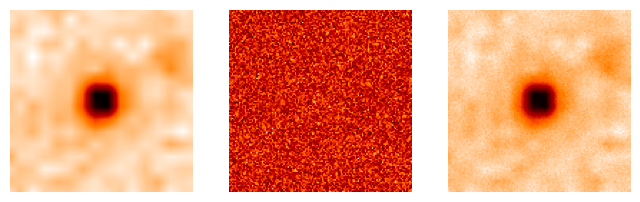

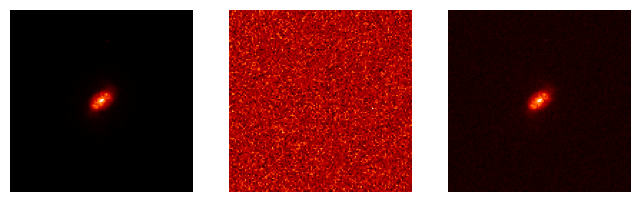

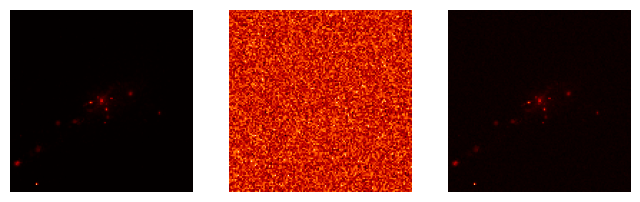

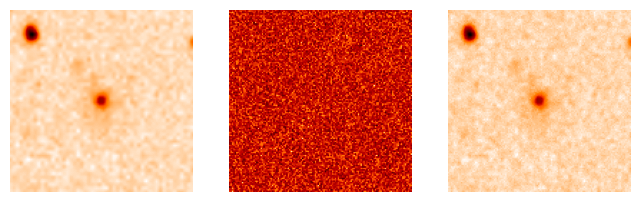

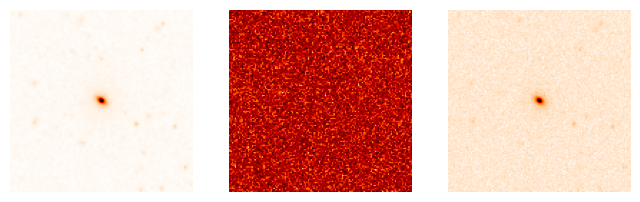

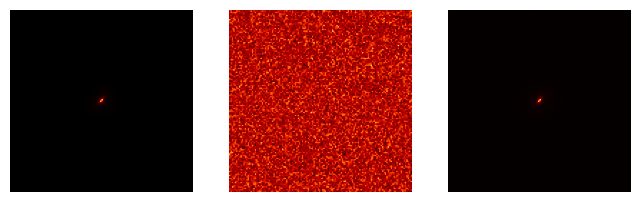

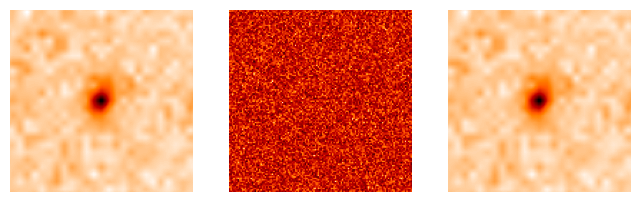

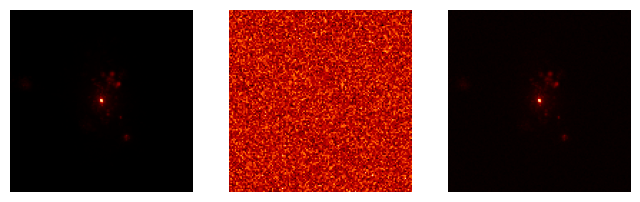

In [53]:
cosmos_dset = load_dataset(train_dataset, 8, 0.01)

%matplotlib inline
for batch in cosmos_dset:
    for i in range(2):
        plt.figure()
        plt.subplot(131)
        plt.imshow(batch[0]['x'][i])
        plt.axis('off')
        plt.subplot(132)
        plt.imshow(batch[0]['u'][i])
        plt.axis('off')
        plt.subplot(133)
        plt.imshow(batch[0]['y'][i])
        plt.axis('off')